<a href="https://colab.research.google.com/github/Yuyang-Yao/Math_-5750_Project2/blob/main/Math5750_project2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Math 5750/6880: Mathematics of Data Science \\
Project 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, RANSACRegressor, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, accuracy_score, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor

import seaborn as sns

# imports and setup

from sklearn.metrics import confusion_matrix # for Q1 classification like mission


from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn import tree, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score, KFold
from sklearn.datasets import load_digits
from sklearn.preprocessing import scale
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords

import re

https://scikit-learn.org/stable/modules/generated/sklearn.random_projection.GaussianRandomProjection.html


An example of how pairwise_distances work with np.corrcoef

In [ ]:

import numpy as np
from sklearn.metrics import pairwise_distances # for computing pairwise distance
import matplotlib.pyplot as plt

X = np.array([0,2,4,6]).reshape(-1,1)
X_r = np.array([1,3,5,7]).reshape(-1,1)

D_original1 = pairwise_distances(X)
D_reduced1  = pairwise_distances(X_r)

print(X)
print(D_original1)
print(D_original1.ravel())

print(np.corrcoef(D_original1.ravel(), D_reduced1.ravel())[0,1])


[[0]
 [2]
 [4]
 [6]]
[[0. 2. 4. 6.]
 [2. 0. 2. 4.]
 [4. 2. 0. 2.]
 [6. 4. 2. 0.]]
[0. 2. 4. 6. 2. 0. 2. 4. 4. 2. 0. 2. 6. 4. 2. 0.]
1.0


X – 4×1 column vector: four samples [0],[2],[4],[6].

D_original1 – 4×4 symmetric matrix of pairwise Euclidean distances between points (|xi−xj|).

D_original1.ravel() – flattens the distance matrix row-wise into a 1D array of 16 elements.

np.corrcoef(...) = 1.0 – perfect correlation; both distance matrices preserve proportional distances exactly.

Sample shape: (1000, 784)


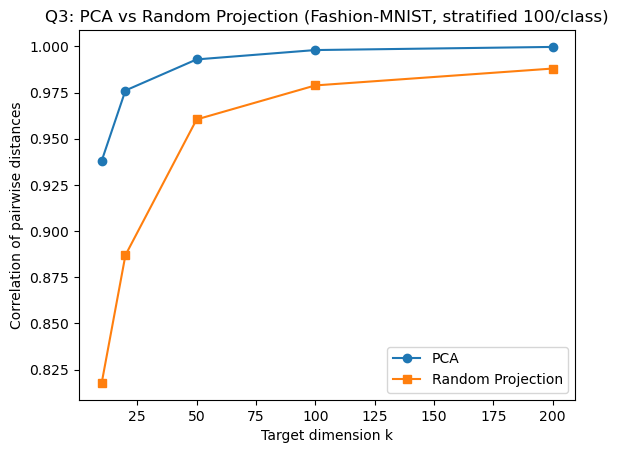

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection
from sklearn.metrics import pairwise_distances # for computing pairwise distance
import matplotlib.pyplot as plt

# Step 1 load data and scale X
X_3, y_3 = fetch_openml("Fashion-MNIST", version=1, as_frame=False, return_X_y=True, parser="auto")
y_3 = y_3.astype(int)# an arry of true class int
X_3_scaled = StandardScaler().fit_transform(X_3)
labels_Q3=np.unique(y_3)

#Step 2Stratified sampling: 1000 per class

sample_index_3 = []
for i in labels_Q3:
    index_class_i = np.where(y_3 == i)[0] # all index for class i
    chosen_index = np.random.choice(index_class_i, 100, replace=False)# radnomly pick 100
    sample_index_3.extend(chosen_index)

X_sample_3 = X_3_scaled[sample_index_3]
y_sample_3 = y_3[sample_index_3]

print("Sample shape:", X_sample_3.shape)


# Step 3.1: Define the correlation function for the " correlation between pairwise distances in the original standardized space and the reduced space."

def correlation_distances(X, X_reduced):
    D_origianl = pairwise_distances(X, n_jobs=-1) #n_jobs=-1?
    D_reduced  = pairwise_distances(X_reduced, n_jobs=-1)
    return np.corrcoef(D_origianl.ravel(), D_reduced.ravel())[0,1]
    # This computes the correlation between all pairwise distances in the original space
    # and the corresponding pairwise distances in the reduced (projected) space — exactly what J–L lemma describes.

#step 3.2 compute correlation for diff dim k
k_values = [10, 20, 50, 100, 200]
corr_pca, corr_rp = [], []

for k in k_values:
    # PCA
    pca = PCA(n_components=k, random_state=42)
    X_pca = pca.fit_transform(X_sample_3)
    corr_pca.append(correlation_distances(X_sample_3, X_pca))

    # Random Projection
    rp = GaussianRandomProjection(n_components=k, random_state=42)
    X_rp = rp.fit_transform(X_sample_3)
    corr_rp.append(correlation_distances(X_sample_3, X_rp))


# Step 4: Plot

plt.plot(k_values, corr_pca, marker='o', label="PCA")
plt.plot(k_values, corr_rp, marker='s', label="Random Projection")
plt.xlabel("Target dimension k")
plt.ylabel("Correlation of pairwise distances")
plt.title("Q3: PCA vs Random Projection (Fashion-MNIST, stratified 100/class)")
plt.legend()
plt.show()


In [ ]:
corr_pca

[0.9509146970260541,
 0.9761069584525836,
 0.9923556504212714,
 0.9980409644892415,
 0.9997348672352611]

in loops for average

In [ ]:
#iniialization

corr_pca_avg_dic_sum=dict.fromkeys(k_values, 0)
corr_rp_avg_dic_sum=dict.fromkeys(k_values, 0)
print(corr_rp_avg_dic_sum)

{10: 0, 20: 0, 50: 0, 100: 0, 200: 0}


Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
Sample shape: (1000, 784)
10 12.021542869376397
20 13.10048254231089
50 14.264216964987025
100 14.606754357901291
200 14.75620965532667
[13.997923301678707, 14.55502613599111, 14.865854174471266, 14.963580930831068, 14.99528964924191]


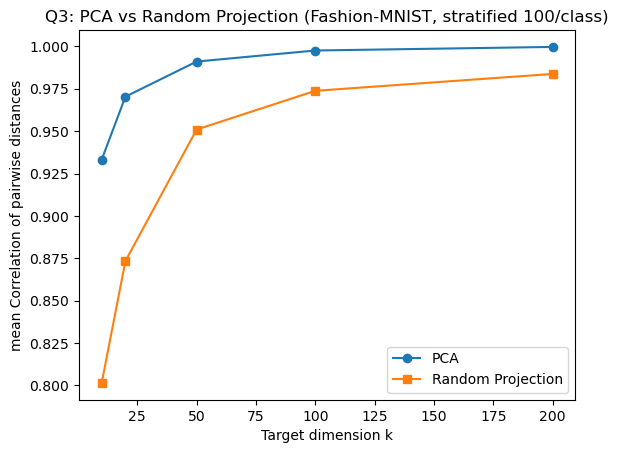

In [ ]:
#Step 2Stratified sampling: 1000 per class
for i in range (0,15):
    sample_index_4 = []
    for i_2 in labels_Q3:
        index_class_i_2 = np.where(y_3 == i_2)[0] # all index for class i
        chosen_index_2 = np.random.choice(index_class_i_2, 100, replace=False)# radnomly pick 100
        sample_index_4.extend(chosen_index_2)

    X_sample_3_2 = X_3_scaled[sample_index_4]
    y_sample_3_2 = y_3[sample_index_4]

    print("Sample shape:", X_sample_3_2.shape)# track for possible debug


    #step 3.2 compute correlation for diff dim k

    for k in k_values:
    # PCA
        pca_2 = PCA(n_components=k, random_state=k)
        X_pca_2 = pca_2.fit_transform(X_sample_3_2)
        corr_coef_k_pca=correlation_distances(X_sample_3_2, X_pca_2)
        corr_pca_avg_dic_sum[k]+=corr_coef_k_pca

    # Random Projection
        rp_2 = GaussianRandomProjection(n_components=k, random_state=42)
        X_rp_2 = rp_2.fit_transform(X_sample_3_2)
        corr_coef_k_rp=correlation_distances(X_sample_3_2, X_rp_2)
        corr_rp_avg_dic_sum[k]+=corr_coef_k_rp

# take values from key to be a list to compute mean corr coef for pairwise dist
for key, value in corr_rp_avg_dic_sum.items():
    print(key, value)


corr_pca_avg_l_sum= list(corr_pca_avg_dic_sum.values())
print(corr_pca_avg_l_sum)
corr_pca_avg=[j/15 for j in corr_pca_avg_l_sum ]

corr_rp_avg_l_sum= list(corr_rp_avg_dic_sum.values())
corr_rp_avg=[m/15 for m in corr_rp_avg_l_sum]

# ------------------------
# Plot
# ------------------------
plt.plot(k_values, corr_pca_avg, marker='o', label="PCA")
plt.plot(k_values, corr_rp_avg, marker='s', label="Random Projection")
plt.xlabel("Target dimension k")
plt.ylabel("mean Correlation of pairwise distances")
plt.title("Q3: PCA vs Random Projection (Fashion-MNIST, stratified 100/class)")
plt.legend()
plt.show()

# Q4
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html

In [ ]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_samples, silhouette_score

In [ ]:
# step 1 choose index for stratification
class_labels=np.unique(y_3)
sample_index_Q4 = []
for k in class_labels:
    index_k = np.where(y_3 == k)[0]
    chosen_index_Q4 = np.random.choice(index_k, 200, replace=False)
    sample_index_Q4.extend(chosen_index_Q4)  # extend([3,4]) → [3,4]; but append([1,2]) → [[3,4]]]

X_sample_Q4 = X_3_scaled[sample_index_Q4]
y_sample_Q4 = y_3[sample_index_Q4]

print("Sample shape:", X_sample_Q4.shape)

Sample shape: (2000, 784)


In [ ]:
np.unique(labels_spec_clustering_KNN)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
Spectral_clustering_KNN = SpectralClustering( # Gausian kernel method for constructing the graph Laplacian
    n_clusters=10,
    affinity="nearest_neighbors",   # uses kNN internally
    n_neighbors=10,           # number of neighbors in kNN grap
    n_components=11,  # use same reduced dim as Q2
    assign_labels="kmeans",
    random_state=42)

labels_spec_clustering_KNN = Spectral_clustering_KNN .fit_predict(X_sample_Q4)
labels_spec_clustering_KNN

array([1, 5, 1, ..., 3, 3, 9])

In [ ]:
#SSE_Q2_s = Spectral_clustering.inertia_
#print("inertia value or SSE:", SSE_Q2_s)

silhouette_score_Q4_spectral_KNN = silhouette_score(X_sample_Q4, labels_spec_clustering_KNN )
print("silhouette_score for Q4 is:", silhouette_score_Q4_spectral_KNN )

silhouette_score for Q4 is: 0.1265402343486762


In [ ]:
homogeneity_completeness_v_measure_Q4_sample_KNN=metrics.homogeneity_completeness_v_measure(y_sample_Q4,labels_spec_clustering_KNN)
print('homogeneity_completeness_v_measure score',homogeneity_completeness_v_measure_Q4_sample_KNN) # Evaluating cluster quality with known ground-truth labels

homogeneity_completeness_v_measure score (0.5790926873910855, 0.6204008194917149, 0.5990354691502173)


Spectral clustering constructs a Laplacian graph that captures nonlinear manifold structures,
so even if geometric distances overlap ( silhouette_score is lower), clustering can better match actual classes.

In [ ]:
import pyamg
Spectral_clustering_rbf = SpectralClustering( # Gausian kernel method for constructing the graph Laplacian
    n_clusters=10,
    affinity="rbf",   # uses kNN internally
    gamma=0.00015,    # bandwith for the Guassian kernel
    eigen_solver="arpack",
    n_components=10, # use same reduced dim as Q2
    assign_labels="kmeans",
    random_state=42)

labels_spec_clustering_rbf = Spectral_clustering_rbf .fit_predict(X_sample_Q4)
labels_spec_clustering_rbf

array([3, 9, 3, ..., 6, 2, 8])

smaller bandwidth (larger γ) makes the kernel more sensitive to local detail → lower bias, higher variance
large γ makes kernels extremely narrow; most affinities ≈0, graph becomes disconnected.
standardized data has small distances (≈1), so γ must be small

In [ ]:
silhouette_score_Q4_spectral_rbf = silhouette_score(X_sample_Q4, labels_spec_clustering_rbf)
print("silhouette_score for Q4 is:", silhouette_score_Q4_spectral_rbf )

silhouette_score for Q4 is: 0.13284768781041395


In [ ]:
homogeneity_completeness_v_measure_Q4_sample_rbf=metrics.homogeneity_completeness_v_measure(y_sample_Q4,labels_spec_clustering_rbf)
print('homogeneity_completeness_v_measure score',homogeneity_completeness_v_measure_Q4_sample_rbf)

homogeneity_completeness_v_measure score (0.5079852096491889, 0.5460878008012867, 0.5263478397162502)


KNN did better than rbf kernel for graph laplacian. So only report confusion matrix for the one using k-nearest neighbor
as graph laplacian L.

https://scikit-learn.org/stable/auto_examples/cluster/plot_adjusted_for_chance_measures.html
https://www.geeksforgeeks.org/dsa/hungarian-algorithm-assignment-problem-set-1-introduction/
4.3 confusion matrix
confusion matrix follows true labels (0–9) in rows for the confusion_matrix_aligned

$\verb|(i%3==0)| $

In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

def hungarian_confusion_matrix(y_true, y_pred_clustering):
    # biuld initial confusion matrix
    original_confusion_matrix = confusion_matrix(y_true, y_pred_clustering)

    # Use Hungarian algorithm to find optimal column permutation
    row_index, col_index = linear_sum_assignment(-original_confusion_matrix )
    # row_ind and col_ind are index arrays showing the optimal one-to-one assignment between true classes (rows) and predicted clusters (columns)
    #that achieves the maximum overall matching.

    # Reorder columns (predicted labels) to best match true classes
    confusion_matrix_aligned = original_confusion_matrix[:, col_index ]
    return  confusion_matrix_aligned, row_index, col_index


confusion_matrix_aligned_Q4, row_index, col_index = hungarian_confusion_matrix(y_sample_Q4, labels_spec_clustering_rbf)
print("Aligned Confusion Matrix:\n", confusion_matrix_aligned_Q4)
print( 're-ordered predicted labels is',col_index)

Aligned Confusion Matrix:
 [[135  16   2   0   2  43   0   0   2   0]
 [  7 184   1   0   0   8   0   0   0   0]
 [  4   0  73   0  72  51   0   0   0   0]
 [  8 128   0   0  16  43   0   1   4   0]
 [  0   8  26   0 139  23   0   0   4   0]
 [  0   0   0  11   1 116   0  58   1  13]
 [ 37   5  28   0  59  69   1   0   1   0]
 [  0   0   0   0   0  17   0 170   0  13]
 [  1   0   2   1   6  19  57  20  94   0]
 [  0   0   0  50   0   7   0   6   0 137]]
re-ordered predicted labels is [9 1 0 8 5 3 4 2 7 6]


In [ ]:
import numpy as np

# From confusion_matrix_aligned (rows = true, col_index = predicted after Hungarian)
TP = np.diag(confusion_matrix_aligned_Q4)
precision = TP / confusion_matrix_aligned_Q4.sum(axis=0)      # per-class precision
recall = TP  / confusion_matrix_aligned_Q4.sum(axis=1)         # per-class recall
accuracy = TP .sum() / confusion_matrix_aligned_Q4.sum()       # overall accuracy

print("Precision:", np.mean(precision))
print("Recall:", np.mean(recall))
print("Accuracy:", accuracy)


Precision: 0.4971051775806023
Recall: 0.5245
Accuracy: 0.5245


In [ ]:
# knn

In [ ]:
confusion_matrix_aligned_Q4_knn, row_index_knn, col_index_knn = hungarian_confusion_matrix(y_sample_Q4, labels_spec_clustering_KNN )
print("Aligned Confusion Matrix:\n", confusion_matrix_aligned_Q4_knn)
print( 're-ordered predicted labels is',col_index_knn)

Aligned Confusion Matrix:
 [[127   0   9  23   1   0  40   0   0   0]
 [  0 186   1   8   0   0   5   0   0   0]
 [  2   0 140   3   0   0  55   0   0   0]
 [  3   0   3 159   1   0  34   0   0   0]
 [  0   0 139  36   1   0  24   0   0   0]
 [  0   0   0   1   0   2  57 120   0  20]
 [ 34   0  88  12   0   0  64   1   1   0]
 [  0   0   0   0   0   0   0 184   0  16]
 [  1   0  11   1  78   0  15  13  77   4]
 [  0   0   0   0   0  48   5   3   0 144]]
re-ordered predicted labels is [5 6 8 0 7 9 1 4 2 3]


In [ ]:
# From confusion_matrix_aligned (rows = true, col_index = predicted after Hungarian)
TP_knn = np.diag(confusion_matrix_aligned_Q4_knn)
precision_knn = TP_knn / confusion_matrix_aligned_Q4_knn.sum(axis=0)      # per-class precision
recall_knn = TP_knn  / confusion_matrix_aligned_Q4_knn.sum(axis=1)         # per-class recall
accuracy_knn = TP_knn .sum() / confusion_matrix_aligned_Q4_knn.sum()       # overall accuracy

print("Precision:", np.mean(precision_knn))
print("Recall:", np.mean(recall_knn))
print("Accuracy:", accuracy_knn)

Precision: 0.5382245702883057
Recall: 0.5419999999999999
Accuracy: 0.542


V-measure (choose t-SNE/UMAP based on structure):
Use when you want to evaluate how well clusters reflect true class relationships overall—good for comparing global structure or manifold quality, not exact label matching.

Accuracy (choose by label alignment):
Use when you need to measure how precisely each cluster corresponds to one true class—good for assessing classification-like performance after Hungarian label alignment.